C:\Users\Administrator\AppData\Local\Temp\ipykernel_13148\2522805885.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13148\2522805885.py:45: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


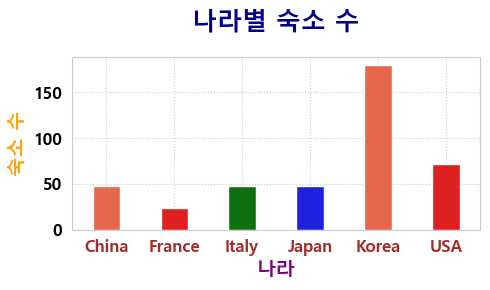

In [306]:
#반드시 pandas는 import하여 사용한다.
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용한다.
import matplotlib.pyplot as plt
# seaborn: matplotlib 기반위에서 차트 이쁘게 꾸미는 도구
import seaborn as sns

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

#호텔 데이터
hotel = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8')
hotelDf = pd.DataFrame(hotel)

#객실 데이터
room = pd.read_csv('greenData/resort/room.csv', encoding='cp949')
roomDf = pd.DataFrame(room)

# 호텔+룸 머지
merged = pd.merge(hotelDf,roomDf,how="inner", on='h_code')
#나라 그룹별 숙소갯수
roomNum = merged.groupby('country')['h_code'].count()
roomNum

# roomNum['도시명'] = roomNum['country'].map({
#     'Korea': '한국',
#     'China': '중국',
#     'France': '프랑스',
#     'Italy': '이탈리아',
#     'Japan': '일본',
#     'USA': '미국'
# })




#seaborn 스타일 지정
sns.set_style('whitegrid') # 배경스타일 설정, dark : 그리드 없이 어두운 배경 지정
sns.set_palette('pastel') # 색상 스타일 지정, deep : 진하게
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(5,3))
ax = sns.barplot(
    #x='숙소 수',
    #y='나라',
    data=roomNum,
    width=0.4,
    palette=['#ff5733','red','green','blue']
)
plt.title("나라별 숙소 수", fontsize=18,fontweight='bold',color='darkblue',pad=20) #차트 제목 여백
plt.xlabel("나라",fontsize=14,fontweight='bold',color='purple')
plt.ylabel("숙소 수",fontsize=14,fontweight='bold',color='orange')
plt.xticks(fontsize=12,fontweight='bold',color='brown')
plt.yticks(fontsize=12,fontweight='bold',color='black')
# for i in range(len(merged['h_code'])):
#     v = merged['h_code'][i] # i번째 병원수 값 출력
#     #print(f"{i}번째 병원수 : {v}")
#     ax.text(
#         i, # x의 위치 (막대위치 : 0,1,2~)
#         v, # y의 위치 (막대높이)
#         int(v), # 정수로 표시할 값
#         ha='center', 
#         va='bottom',
#         fontsize=12,
#         fontweight='bold',
#         color='red'
#     )
plt.grid(linestyle=':') #촘촘한선

plt.tight_layout()

plt.show()
#roomNum



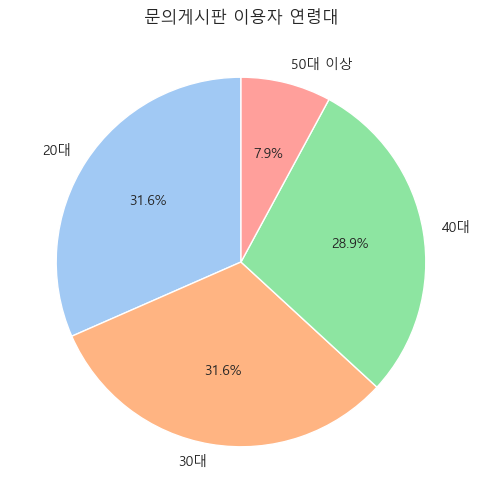

In [462]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기


# #회원 데이터
member = pd.read_csv('greenData/resort/member.csv', encoding='utf-8')
memberDf = pd.DataFrame(member)
#관리자 제외한 회원필터
memberFilter = memberDf[memberDf['m_code'] != 301]

# #문의게시판 데이터
board = pd.read_csv('greenData/resort/board.csv', encoding='cp949')
boardDf = pd.DataFrame(board)

# # 문의게시판+회원 머지
merged = pd.merge(memberFilter,boardDf,how="inner", on='m_code')


merged['m_birth'] = pd.to_datetime(merged['m_birth'])
merged['m_birth']


for i in range(len(merged['m_birth'])):
    if (merged['m_birth'][i] >= pd.to_datetime('1997-01-01')) & (merged['m_birth'][i] < pd.to_datetime('2007-01-01')):
        merged.loc[i, '연령대'] = '20대'
    elif (merged['m_birth'][i] >= pd.to_datetime('1987-01-01')) & (merged['m_birth'][i] < pd.to_datetime('1997-01-01')):
        merged.loc[i, '연령대'] = '30대'
    elif (merged['m_birth'][i] >= pd.to_datetime('1977-01-01')) & (merged['m_birth'][i] < pd.to_datetime('1987-01-01')):
        merged.loc[i, '연령대'] = '40대'
    else:
        merged.loc[i, '연령대'] = '50대 이상'
        
result = merged.groupby('연령대')['m_code'].count().reset_index()
result

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,6))

# 원형 그래프 만들기 : plt.pie(항목)
# labels = merged['지역'] =>원형 그래프 각각 파이의 이름
# autopct = '%1.1f%%' => 원형 그래프 각 조각의 백분율 출력
# startangle = 90 => 원형 그래프 시작 위치, 90이면 위쪽부터 시작
plt.pie(
    result['m_code'],          # 값 (숫자)
    labels=result['연령대'],   # 라벨 (이름)
    autopct='%1.1f%%',
    startangle=90
)



# 원형 그래프는 x,y축이 필요하지 않다.
plt.title('문의게시판 이용자 연령대')
plt.show()



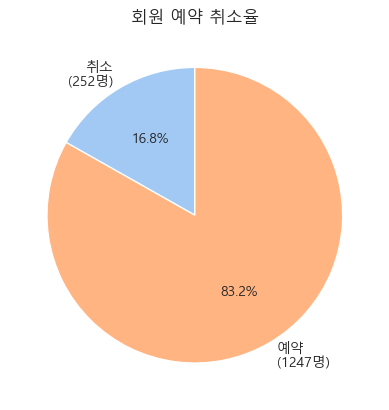

In [461]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

# #회원 데이터
member = pd.read_csv('greenData/resort/member.csv', encoding='utf-8')
memberDf = pd.DataFrame(member)
#관리자 제외한 회원필터
memberFilter = memberDf[memberDf['m_code'] != 301]

# #예약 데이터
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)


#유형별 취소수
reservationDf['유형'] = '회원'
reservationDf.loc[reservationDf['m_code'] == 0, '유형'] = '비회원'

reservationDf['취소'] = 0
reservationDf.loc[reservationDf['cancel'] == 1, '취소'] += 1

#취소율 결과
result = reservationDf.groupby('유형')['cancel'].agg(['count','sum']).reset_index()
result['취소율'] = result['sum'] / result['count'] * 100
result


# 회원 데이터
member = result[result['유형'] == '회원']

cancel = member['sum'].values[0]
reserv = member['count'].values[0]-cancel

labels.loc[0] = '취소\n(' + str(cancel) + '명)'
labels.loc[1] = '예약\n(' + str(reserv) + '명)'

plt.figure()

plt.pie(
    [cancel, reserv],
    labels=labels,
    #autopct='%1.1f%%',
    autopct='%1.1f%%',
    startangle=90
)

plt.title(f'회원 예약 취소율')
plt.show()


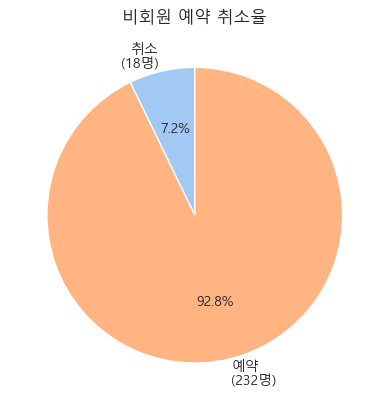

In [460]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

# #회원 데이터
member = pd.read_csv('greenData/resort/member.csv', encoding='utf-8')
memberDf = pd.DataFrame(member)
#관리자 제외한 회원필터
memberFilter = memberDf[memberDf['m_code'] != 301]

# #예약 데이터
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)


#유형별 취소수
reservationDf['유형'] = '회원'
reservationDf.loc[reservationDf['m_code'] == 0, '유형'] = '비회원'

reservationDf['취소'] = 0
reservationDf.loc[reservationDf['cancel'] == 1, '취소'] += 1

#취소율 결과
result = reservationDf.groupby('유형')['cancel'].agg(['count','sum']).reset_index()
result['취소율'] = result['sum'] / result['count'] * 100
result



# 비회원 데이터
non_member = result[result['유형'] == '비회원']

cancel = non_member['sum'].values[0]
reserv = non_member['count'].values[0]-cancel


labels.loc[0] = '취소\n(' + str(cancel) + '명)'
labels.loc[1] = '예약\n(' + str(reserv) + '명)'

plt.figure()

plt.pie(
    [cancel, reserv],
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(f'비회원 예약 취소율')
plt.show()


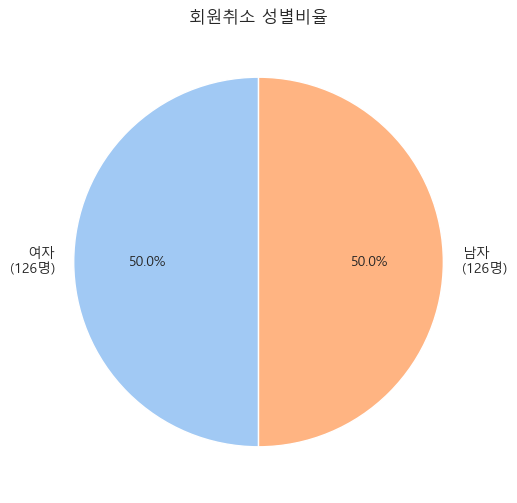

In [459]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

# #회원 데이터
member = pd.read_csv('greenData/resort/member.csv', encoding='utf-8')
memberDf = pd.DataFrame(member)
#관리자 제외한 회원필터
memberFilter = memberDf[memberDf['m_code'] != 301]

# #예약 데이터
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)
#print(reservationDf)
#reservation

#유형별 취소수
reservationDf['유형'] = '회원'
reservationDf.loc[reservationDf['m_code'] == 0, '유형'] = '비회원'

reservationDf['취소'] = 0
reservationDf.loc[reservationDf['cancel'] == 1, '취소'] += 1


## 예약+회원 머지
merged01 = pd.merge(memberFilter,reservationDf,how="inner", on='m_code')

#취소한 회원정보
merged01 = merged01[merged01['cancel'] == 1]
merged01['성별'] = "남자"
merged01.loc[merged01['m_gender'] == 1, '성별'] = "여자"


result = merged01['성별'].value_counts().reset_index()
result.columns = ['성별', '인원수']

result['비율'] = result['인원수'] / result['인원수'].sum() * 100


result

labels = result['성별'] + '\n(' + result['인원수'].astype(str) + '명)'


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,6))
# 원형 그래프 만들기 : plt.pie(항목)
# labels = merged['지역'] =>원형 그래프 각각 파이의 이름
# autopct = '%1.1f%%' => 원형 그래프 각 조각의 백분율 출력
# startangle = 90 => 원형 그래프 시작 위치, 90이면 위쪽부터 시작
plt.pie(result['비율'], labels=labels, autopct='%1.1f%%', startangle=90)

# 원형 그래프는 x,y축이 필요하지 않다.
plt.title(f"회원취소 성별비율")
plt.show()


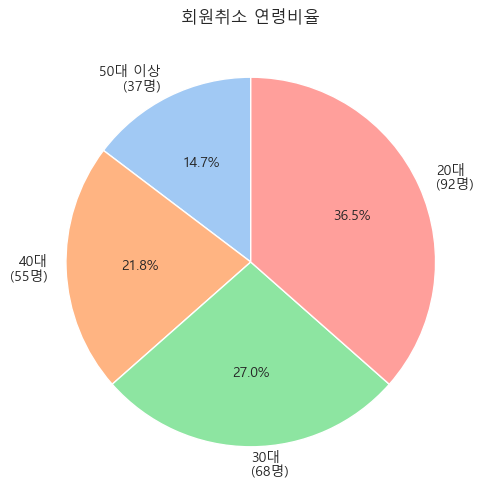

In [533]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

# #회원 데이터
member = pd.read_csv('greenData/resort/member.csv', encoding='utf-8')
memberDf = pd.DataFrame(member)
#관리자 제외한 회원필터
memberFilter = memberDf[memberDf['m_code'] != 301]

# #예약 데이터
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)

#유형별 취소수
reservationDf['유형'] = '회원'
reservationDf.loc[reservationDf['m_code'] == 0, '유형'] = '비회원'

reservationDf['취소'] = 0
reservationDf.loc[reservationDf['cancel'] == 1, '취소'] += 1

#취소율 결과
result = reservationDf.groupby('유형')['cancel'].agg(['count','sum']).reset_index()
result['취소율'] = result['sum'] / result['count'] * 100

## 예약+회원 머지
merged01 = pd.merge(memberFilter,reservationDf,how="inner", on='m_code')

#취소한 회원정보
merged01 = merged01[merged01['cancel'] == 1]
merged01['성별'] = "남자"
merged01.loc[merged01['m_gender'] == 1, '성별'] = "여자"

# merged01['m_birth'] = pd.to_datetime(merged01['m_birth'])

merged01['연령대'] = '50대 이상'

merged01.loc[
    (merged01['m_birth'] >= '1997-01-01') & (merged01['m_birth'] < '2007-01-01'),
    '연령대'
] = '20대'

merged01.loc[
    (merged01['m_birth'] >= '1987-01-01') & (merged01['m_birth'] < '1997-01-01'),
    '연령대'
] = '30대'

merged01.loc[
    (merged01['m_birth'] >= '1977-01-01') & (merged01['m_birth'] < '1987-01-01'),
    '연령대'
] = '40대'


result = merged01['연령대'].value_counts().reset_index()
result.columns = ['연령대', '인원수']

result['비율'] = result['인원수'] / result['인원수'].sum() * 100

result['인원수']

result = result.iloc[::-1]


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,6))

labels = result['연령대'] + '\n(' + result['인원수'].astype(str) + '명)'

# 원형 그래프 만들기 : plt.pie(항목)
# labels = merged['지역'] =>원형 그래프 각각 파이의 이름
# autopct = '%1.1f%%' => 원형 그래프 각 조각의 백분율 출력
# startangle = 90 => 원형 그래프 시작 위치, 90이면 위쪽부터 시작
plt.pie(
    result['비율'],          # 값 (숫자)
    labels=labels,   # 라벨 (이름)
    autopct='%1.1f%%',
    startangle=90,
)


# 원형 그래프는 x,y축이 필요하지 않다.
plt.title('회원취소 연령비율')
plt.show()


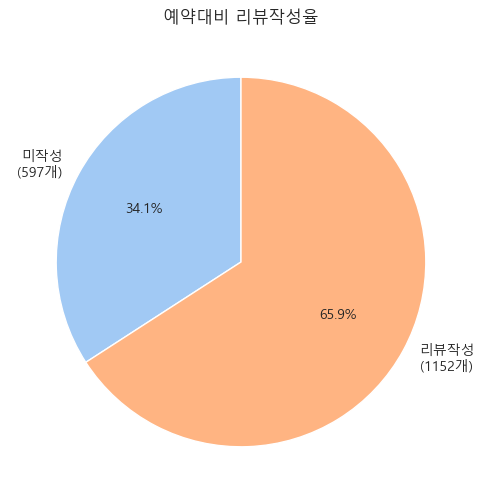

In [493]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

# #리뷰 데이터
reviewboard = pd.read_csv('greenData/resort/reviewboard.csv', encoding='utf-8')
reviewboardrDf = pd.DataFrame(reviewboard)
#관리자 제외한 회원필터
reviewboardFilter = reviewboardrDf[reviewboardrDf['m_code'] != 301]

# #예약 데이터
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)

result03 = pd.DataFrame({
    '예약수': [len(reservationDf)],
    '리뷰수': [reviewboardFilter['rb_code'].count()],
    '비율': (reviewboardFilter['rb_code'].count() / len(reservationDf)) * 100
})

review = result03['리뷰수'][0]
total = result03['예약수'][0]

not_review = total - review

labels = [
    f'미작성\n(' + str(result03['예약수'][0]-result03['리뷰수'][0]) + '개)',
    f'리뷰작성\n(' + str(result03['리뷰수'][0]) + '개)'
]


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,6))

plt.pie([not_review, review], labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('예약대비 리뷰작성율')
plt.show()

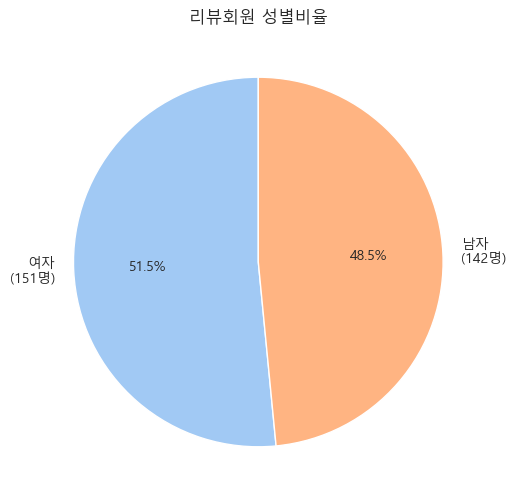

In [515]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

# #회원 데이터
member = pd.read_csv('greenData/resort/member.csv', encoding='utf-8')
memberDf = pd.DataFrame(member)
#관리자 제외한 회원필터
memberFilter = memberDf[memberDf['m_code'] != 301]

# #리뷰 데이터
reviewboard = pd.read_csv('greenData/resort/reviewboard.csv', encoding='utf-8')
reviewboardrDf = pd.DataFrame(reviewboard)
#관리자 제외한 회원필터
reviewboardFilter = reviewboardrDf[reviewboardrDf['m_code'] != 301]

## 리뷰+회원 머지
merged05 = pd.merge(reviewboardFilter,memberFilter,how="inner", on='m_code')

#취소한 회원정보

merged05['성별'] = "남자"
merged05.loc[merged05['m_gender'] == 1, '성별'] = "여자"

merged05Filter = merged05.groupby('m_code').first().reset_index()

result05 = merged05Filter['성별'].value_counts().reset_index()
result05.columns = ['성별', '인원수']

result05['비율'] = result05['인원수'] / result05['인원수'].sum() * 100


comment_count = merged05['성별'].value_counts()
result05['댓글수'] = result05['성별'].map(comment_count)

result05

labels = result05['성별'] + '\n(' + result05['인원수'].astype(str) + '명)'


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,6))

plt.pie(result05['비율'], labels=labels, autopct='%1.1f%%', startangle=90)

# # 원형 그래프는 x,y축이 필요하지 않다.
plt.title(f"리뷰회원 성별비율")
plt.show()


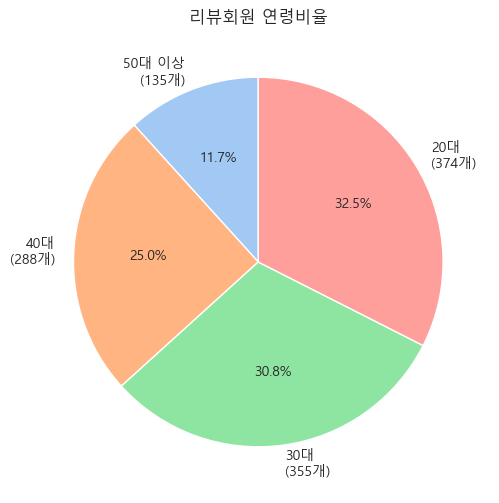

In [531]:
import pandas as pd
import matplotlib.pyplot as plt

#출력옵션 설정
pd.set_option('display.max_columns',None) #모든컬럼 출력
pd.set_option('display.width',1000) #출력너비 지정
pd.set_option('display.unicode.east_asian_width',True) #한글정렬 맞추기

# #회원 데이터
member = pd.read_csv('greenData/resort/member.csv', encoding='utf-8')
memberDf = pd.DataFrame(member)
#관리자 제외한 회원필터
memberFilter = memberDf[memberDf['m_code'] != 301]

# #리뷰 데이터
reviewboard = pd.read_csv('greenData/resort/reviewboard.csv', encoding='utf-8')
reviewboardrDf = pd.DataFrame(reviewboard)
#관리자 제외한 회원필터
reviewboardFilter = reviewboardrDf[reviewboardrDf['m_code'] != 301]

## 리뷰+회원 머지
merged06 = pd.merge(reviewboardFilter,memberFilter,how="inner", on='m_code')

merged06['연령대'] = '50대 이상'

merged06.loc[
    (merged06['m_birth'] >= '1997-01-01') & (merged06['m_birth'] < '2007-01-01'),
    '연령대'
] = '20대'

merged06.loc[
    (merged06['m_birth'] >= '1987-01-01') & (merged06['m_birth'] < '1997-01-01'),
    '연령대'
] = '30대'

merged06.loc[
    (merged06['m_birth'] >= '1977-01-01') & (merged06['m_birth'] < '1987-01-01'),
    '연령대'
] = '40대'


result06 = merged06['연령대'].value_counts().reset_index()
result06.columns = ['연령대', '댓글수']

result06['비율'] = (result06['댓글수'] / result06['댓글수'].sum()) * 100

result06 = result06.iloc[::-1]


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,6))

labels06 = result06['연령대'] + '\n(' + result06['댓글수'].astype(str) + '개)'


plt.pie(
    result06['비율'],          # 값 (숫자)
    labels=labels06,   # 라벨 (이름)
    autopct='%1.1f%%',
    startangle=90,
)


# 원형 그래프는 x,y축이 필요하지 않다.
plt.title('리뷰회원 연령비율')
plt.show()